In [1]:
!pip install tensorflow
!pip install optuna
!pip install scikit-learn

In [13]:
!unzip ./dataset.zip
!rm -rf ./__MACOSX/

In [2]:
import tensorflow as tf
import optuna
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array


print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)
gpu = tf.config.list_physical_devices('GPU')
print(f"GPU Name: {tf.test.gpu_device_name()}")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF Version: 2.20.0
GPU Name: /device:GPU:0


In [3]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 228
IMG_WIDTH = 228

BATCH_SIZE=16


In [4]:
# ============================================
# IMAGE DATA GENERATOR
# ===========================================

train_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=10,
  zoom_range=0.2,
  horizontal_flip=True,
  vertical_flip=True,
)

validation_datagen = ImageDataGenerator(
  rescale=1./255,
)


In [5]:
# ============================================
# LOAD IMAGE
# ===========================================

train_dir = "dataset/train"
validation_dir = "dataset/val"
test_dir = "dataset/test"

train_data = train_datagen.flow_from_directory(
  train_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary'
)

validation_data = validation_datagen.flow_from_directory(
  validation_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary' ,
  shuffle=False,
)

test_data = validation_datagen.flow_from_directory(
  test_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary',
  shuffle=False
)

print(train_data.class_indices)

Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [8]:
# ============================================
# OPTUNA OPTIMATION
# ===========================================
from sklearn.metrics import f1_score, roc_auc_score, recall_score, accuracy_score

def objective(trial: optuna.Trial):
  model = tf.keras.models.Sequential()

  n_conv = trial.suggest_int('n_conv', 2, 4)
  lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
  n_dense = trial.suggest_int('n_dense', 1, 3)

  # INPUT CONV2D
  model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), padding='same'))
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.MaxPooling2D())

  for i in range(n_conv):
    filters = trial.suggest_categorical(f'filters_{i}', [64, 128, 256])
    conv_dropout = trial.suggest_float(f'conv_droprate_{i}', 0.2, 0.4, step=0.05)
    model.add(tf.keras.layers.Conv2D(filters, (3, 3), activation='relu', padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Dropout(conv_dropout))

  # FULLY CONNECTED LAYERS
  model.add(tf.keras.layers.Flatten())
  for i in range(n_dense):
    dense_unit = trial.suggest_categorical(f'dense_unit_{i}', [128, 256, 512])
    dense_dropout = trial.suggest_float(f'dense_droprate_{i}', 0.2, 0.4, step=0.05)
    model.add(tf.keras.layers.Dense(dense_unit, activation='relu'))
    model.add(tf.keras.layers.Dropout(dense_dropout))

  # OUTPUT LAYER
  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=[
      'accuracy',
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.AUC(name='auc')
    ]
  )

  callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
  ]

  model.fit(
    train_data,
    validation_data=validation_data,
    epochs=100,
    callbacks=callbacks,
    verbose=0,
    batch_size=BATCH_SIZE,
  )

  # f1 score validation data
  validation_data.reset()
  y_prob = model.predict(validation_data).flatten()
  y_pred = (y_prob > 0.5).astype(int)
  y_true = validation_data.classes

  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_prob)
  accuracy = accuracy_score(y_true, y_pred)

  trial.set_user_attr('recall', recall)
  trial.set_user_attr('auc', auc)
  trial.set_user_attr('f1', f1)
  trial.set_user_attr('accuracy', accuracy)

  print("===============TRIAL======================")
  print(f"Trial Recall       : {recall}")
  print(f"Trial AUC          : {auc}")
  print(f"Trial F1           : {f1}")
  print(f"Trial Accuracy     : {accuracy}")

  scoring = 0.5 * recall + 0.5 * auc
  return scoring

In [10]:
# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(direction='maximize', study_name='model-tunning')
study.optimize(objective,n_trials=20)
best_trial = study.best_trial
print("\n================ FINAL =====================")
print(f"Best Score        : {best_trial.value:.4f}")
print(f"Best AUC          : {best_trial.user_attrs['auc']:.4f}")
print(f"Best Recall       : {best_trial.user_attrs['recall']:.4f}")
print(f"Best F1           : {best_trial.user_attrs['f1']:.4f}")
print(f"Best Accuracy     : {best_trial.user_attrs['accuracy']:.4f}")
print(f"Best Params       : {best_trial.params}")

[I 2026-05-19 05:03:33,622] A new study created in memory with name: model-tunning
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step


[I 2026-05-19 05:04:23,715] Trial 0 finished with value: 0.9497453310696095 and parameters: {'n_conv': 2, 'learning_rate': 1.779154534375671e-05, 'n_dense': 3, 'filters_0': 128, 'conv_droprate_0': 0.30000000000000004, 'filters_1': 128, 'conv_droprate_1': 0.4, 'dense_unit_0': 256, 'dense_droprate_0': 0.4, 'dense_unit_1': 256, 'dense_droprate_1': 0.30000000000000004, 'dense_unit_2': 256, 'dense_droprate_2': 0.35000000000000003}. Best is trial 0 with value: 0.9497453310696095.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


===============TRIAL======================
Trial Recall       : 1.0
Trial AUC          : 0.8743633276740237
Trial F1           : 0.7654320987654321
Trial Accuracy     : 0.62
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step


...

===============TRIAL======================
Trial Recall       : 0.06451612903225806
Trial AUC          : 0.8913412563667232
Trial F1           : 0.12121212121212122
Trial Accuracy     : 0.42


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step


[I 2026-05-19 05:32:39,114] Trial 19 finished with value: 0.964006791171477 and parameters: {'n_conv': 4, 'learning_rate': 0.0004790369278867898, 'n_dense': 3, 'filters_0': 64, 'conv_droprate_0': 0.30000000000000004, 'filters_1': 128, 'conv_droprate_1': 0.35000000000000003, 'filters_2': 128, 'conv_droprate_2': 0.4, 'filters_3': 256, 'conv_droprate_3': 0.30000000000000004, 'dense_unit_0': 128, 'dense_droprate_0': 0.35000000000000003, 'dense_unit_1': 512, 'dense_droprate_1': 0.2, 'dense_unit_2': 512, 'dense_droprate_2': 0.4}. Best is trial 16 with value: 0.9687606112054329.


===============TRIAL======================
Trial Recall       : 1.0
Trial AUC          : 0.9100169779286926
Trial F1           : 0.8611111111111112
Trial Accuracy     : 0.8

================ FINAL =====================
Best Score        : 0.9688
Best AUC          : 0.9219
Best Recall       : 1.0000
Best F1           : 0.8611
Best Accuracy     : 0.8000
Best Params       : {'n_conv': 2, 'learning_rate': 0.00039392628972318783, 'n_dense': 3, 'filters_0': 128, 'conv_droprate_0': 0.30000000000000004, 'filters_1': 64, 'conv_droprate_1': 0.2, 'dense_unit_0': 128, 'dense_droprate_0': 0.2, 'dense_unit_1': 512, 'dense_droprate_1': 0.30000000000000004, 'dense_unit_2': 512, 'dense_droprate_2': 0.4}


In [11]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# =========================================================

model = tf.keras.models.Sequential()
best_param = best_trial.params
# INPUT CONV2D
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

for i in range(best_param['n_conv']):
  model.add(tf.keras.layers.Conv2D(best_param[f'filters_{i}'], (3, 3), activation='relu', padding='same'))
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.MaxPooling2D())
  model.add(tf.keras.layers.Dropout(best_param[f'conv_droprate_{i}']))

# FULLY CONNECTED LAYERS
model.add(tf.keras.layers.Flatten())
for i in range(best_param['n_dense']):
  model.add(tf.keras.layers.Dense(best_param[f'dense_unit_{i}'], activation='relu'))
  model.add(tf.keras.layers.Dropout(best_param[f'dense_droprate_{i}']))

# OUTPUT LAYER
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=best_param['learning_rate']),
  loss='binary_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
  ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_95 (Conv2D)              │ (None, 228, 228, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 228, 228, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_95 (MaxPooling2D) │ (None, 114, 114, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 114, 114, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 114, 114, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_96 (MaxPooling2D) │ (None, 57, 57, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_125 (Dropout)           │ (None, 57, 57, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 57, 57, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_97          │ (None, 57, 57, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_97 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_127 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_129 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,864,449 (26.19 MB)

 Trainable params: 6,864,001 (26.18 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
# =========================================================
# MODEL FIT WITH BEST PARAM
# =========================================================

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

# f1 score validation data
validation_data.reset()
y_prob = model.predict(validation_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = validation_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.8068 - auc: 0.8191 - loss: 0.4939 - precision: 0.7803 - recall: 0.9537 - val_accuracy: 0.8000 - val_auc: 0.9465 - val_loss: 0.3420 - val_precision: 0.7838 - val_recall: 0.9355 - learning_rate: 2.4043e-08
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.7102 - auc: 0.7726 - loss: 0.5744 - precision: 0.7176 - recall: 0.8704 - val_accuracy: 0.8000 - val_auc: 0.9423 - val_loss: 0.3443 - val_precision: 0.7838 - val_recall: 0.9355 - learning_rate: 2.4043e-08
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - accuracy: 0.7273 - auc: 0.7934 - loss: 0.5385 - precision: 0.7273 - recall: 0.8889 - val_accuracy: 0.7800 - val_auc: 0.9423 - val_loss: 0.3463 - val_precision: 0.7778 - val_recall: 0.9032 - learning_rate: 2.4043e-08
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.7273 - auc: 0.7813 - loss: 0.5374 - precision: 0.7206 - recall: 0.9074 - val_accuracy: 0.7800 - val_auc: 0.9423 - val_lo

In [23]:
loss, accuracy, auc, precision, recall = model.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
print(f"Test Loss: {loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7778 - auc: 0.9091 - loss: 0.3764 - precision: 0.7500 - recall: 0.9375

Test Accuracy: 0.7777777910232544
Test Precision: 0.75
Test Recall: 0.9090908765792847
Test AUC: 0.9375
Test Loss: 0.3763584494590759


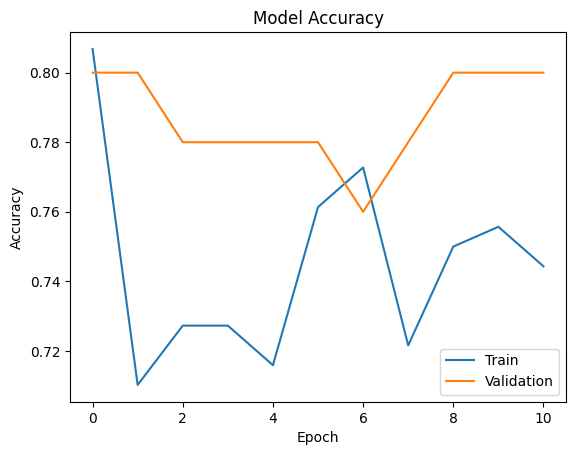

In [24]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

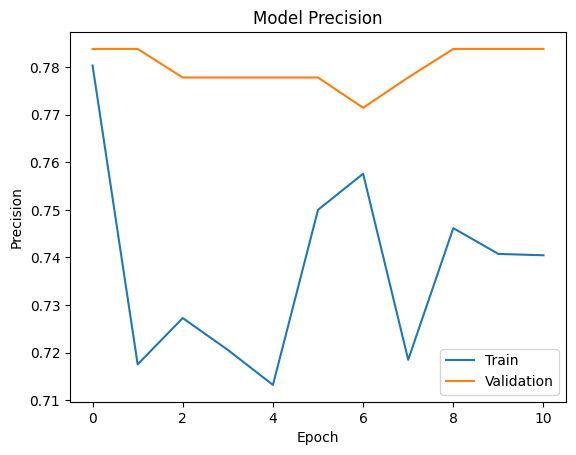

In [25]:
# =========================================================
# VISUALIZATION PRECISION
# =========================================================

plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Train', 'Validation'])
plt.show()

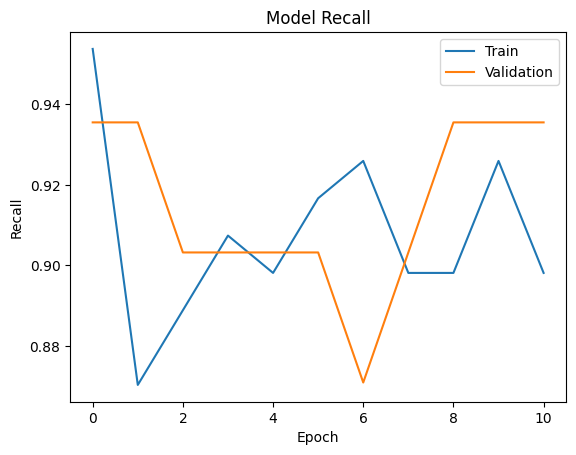

In [26]:
# =========================================================
# VISUALIZATION RECALL
# =========================================================

plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Train', 'Validation'])
plt.show()

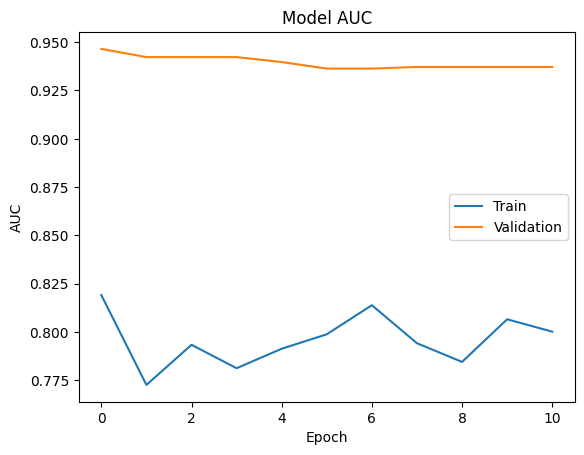

In [27]:
# =========================================================
# VISUALIZATION AUC
# =========================================================

plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(['Train', 'Validation'])
plt.show()

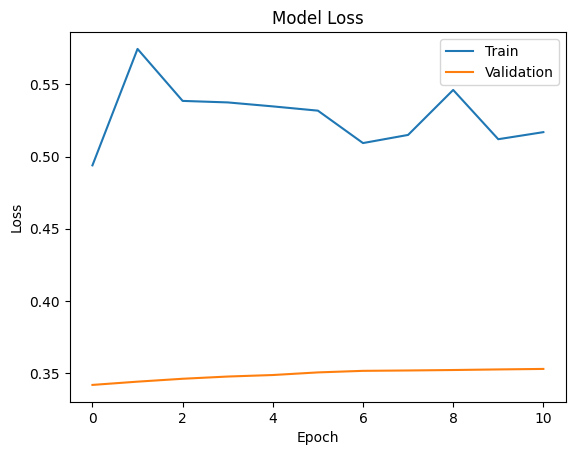

In [28]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [29]:
# =========================================================
# TEST SAMPLE
# =========================================================

image_path = "sample-no.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Prediction Probability:
[[0.25016513]]

Predicted Class:
no


In [31]:
image_path = "sample-yes.JPG"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Prediction Probability:
[[0.850704]]

Predicted Class:
yes
